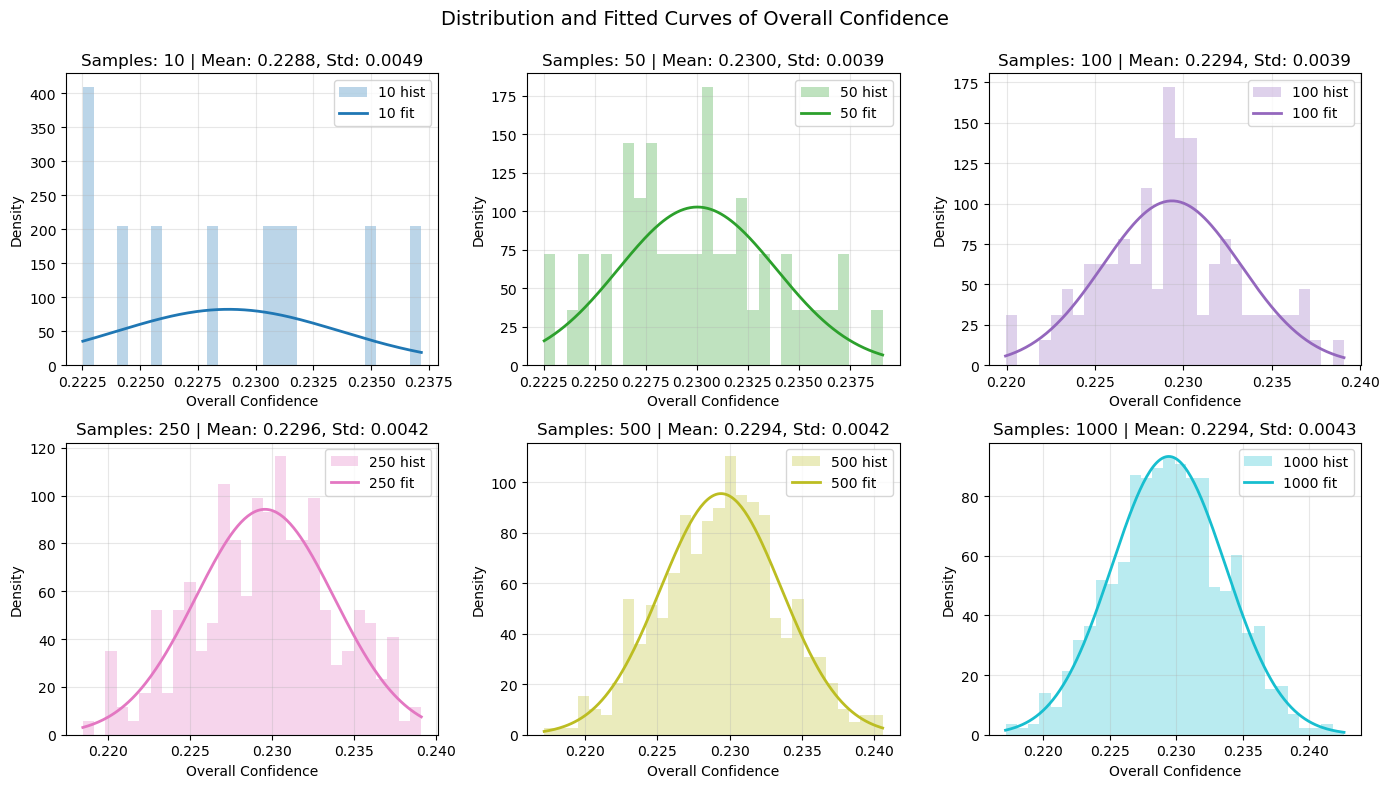

In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def overall_confidence_from_score_pt(pt_path: str):
    d = torch.load(pt_path, map_location="cpu")
    # inputs from score.py
    log_probs = torch.tensor(d["log_probs"], dtype=torch.float32)  # [N, L, 21]
    native_seq = torch.tensor(d["native_sequence"], dtype=torch.long)  # [L]
    mask = torch.tensor(d["mask"], dtype=torch.float32)  # [L]
    chain_mask = torch.tensor(d["chain_mask"], dtype=torch.float32)  # [L]
    m = mask * chain_mask  # [L]

    # broadcast native sequence across all samples N
    N, L, _ = log_probs.shape
    S_one_hot = torch.nn.functional.one_hot(native_seq, num_classes=21).float()  # [L, 21]
    S_one_hot = S_one_hot.unsqueeze(0).repeat(N, 1, 1)  # [N, L, 21]

    loss_per_pos = -(S_one_hot * log_probs).sum(-1)  # [N, L]
    loss = (loss_per_pos * m).sum(-1) / (m.sum() + 1e-8)  # [N]
    overall_confidence = torch.exp(-loss)  # [N]
    return overall_confidence

# for i in [10, 100, 500, 1000]:
#     print(f"Overall confidence for {i} samples: {overall_confidence_from_score_pt(f'./{i}_times/1a0n_1.pt')}")

# 画出不同采样次数下overall confidence的分布情况

sample_sizes = [10, 50, 100, 250, 500, 1000]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(sample_sizes)))

for ax, color, s in zip(axes.ravel(), colors, sample_sizes):
    confs = overall_confidence_from_score_pt(f'./{s}_times/1a0n_1.pt').numpy()
    mu, sigma = confs.mean(), confs.std()
    xs = np.linspace(confs.min(), confs.max(), 200)
    ax.hist(confs, bins=30, density=True, alpha=0.3, color=color, label=f'{s} hist')
    ax.plot(xs, 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2),
            color=color, linewidth=2, label=f'{s} fit')
    ax.set_title(f'Samples: {s} | Mean: {mu:.4f}, Std: {sigma:.4f}')
    ax.set_xlabel('Overall Confidence')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Distribution and Fitted Curves of Overall Confidence', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# pytorch中的randn的分布情况

样本数量       | 均值 (Mean)       | 标准差 (Std)      
---------------------------------------------
100            | 0.0332          | 0.9291         
1000           | -0.0107         | 1.0434         
10000          | 0.0138          | 0.9885         
100000         | -0.0045         | 1.0034         


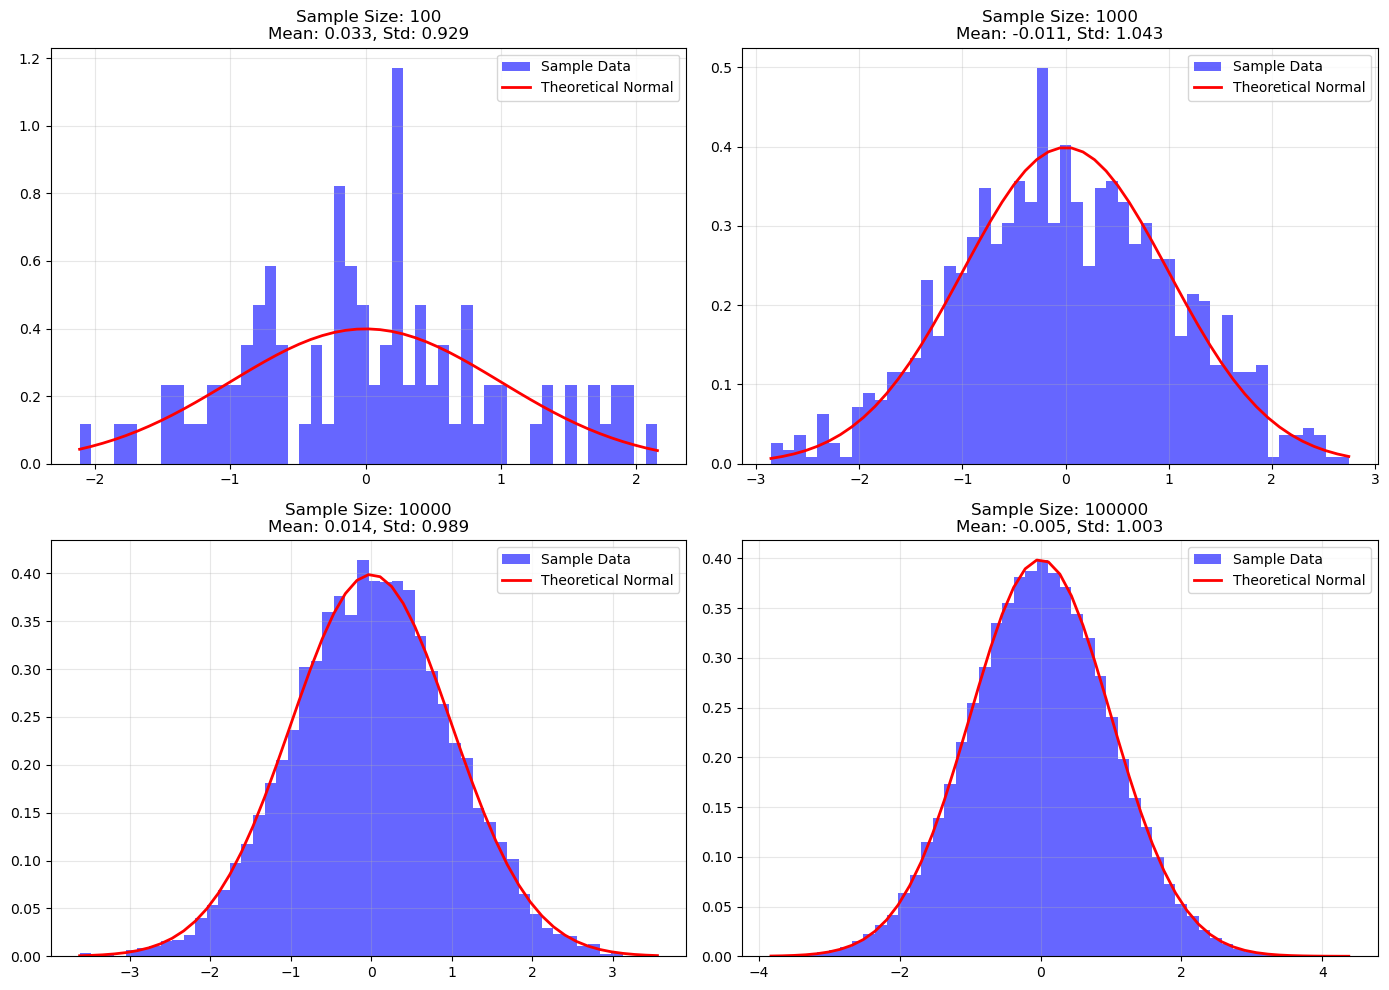

In [13]:
import torch
import matplotlib.pyplot as plt
import math

def verify_normal_distribution():
    # 1. 定义我们要测试的样本数量列表
    sample_sizes = [100, 1000, 10000, 100000]
    
    # 设置画布大小
    plt.figure(figsize=(14, 10))
    
    print(f"{'样本数量':<10} | {'均值 (Mean)':<15} | {'标准差 (Std)':<15}")
    print("-" * 45)

    # 2. 循环遍历不同的样本数量，生成数据并绘图
    for i, size in enumerate(sample_sizes):
        # 使用 torch.randn 生成标准正态分布数据
        # torch.randn 生成的数据理论上均值为0，方差为1
        data = torch.randn(size)
        
        # 计算实际的统计数据
        actual_mean = torch.mean(data).item()
        actual_std = torch.std(data).item()
        
        # 打印统计结果，观察其是否趋近于 0 和 1
        print(f"{size:<14} | {actual_mean:<15.4f} | {actual_std:<15.4f}")
        
        # 绘制子图
        plt.subplot(2, 2, i+1)
        
        # 绘制直方图，bins表示柱子的数量，density=True表示进行归一化显示概率密度
        count, bins, ignored = plt.hist(data.numpy(), bins=50, density=True, alpha=0.6, color='b', label='Sample Data')
        
        # 绘制理论上的正态分布曲线（红色线条）作为对比
        mu, sigma = 0, 1
        plt.plot(bins, 1/(sigma * math.sqrt(2 * math.pi)) * np_exp(bins, mu, sigma), 
                 linewidth=2, color='r', label='Theoretical Normal')
        
        plt.title(f'Sample Size: {size}\nMean: {actual_mean:.3f}, Std: {actual_std:.3f}')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 辅助函数：用于计算理论正态分布曲线的Y值（为了不依赖numpy，我们手动写一个简单的计算）
def np_exp(x_vals, mu, sigma):
    import numpy as np
    return np.exp(-(x_vals - mu)**2 / (2 * sigma**2))

if __name__ == "__main__":
    verify_normal_distribution()